Computing sigmas for all 4096 kernels (this will take a few minutes)...
Done. Mean sigma: 0.0598

Vulnerability Classification — ResNet-18 Layer 1
  Band         Range                   Count       %
  --------------------------------------------------
  Critical     [0.000, 0.001)           151    3.7%
  High Risk    [0.001, 0.005)           589   14.4%
  Moderate     [0.005, 0.050)          2314   56.5%
  Robust       [0.050, ∞)          1042   25.4%

  Mean sigma:   0.0598
  Median sigma: 0.0200
  Max sigma:    0.9786  (Kernel 3503)
  Min sigma:    2.90e-07  (Kernel 2905)


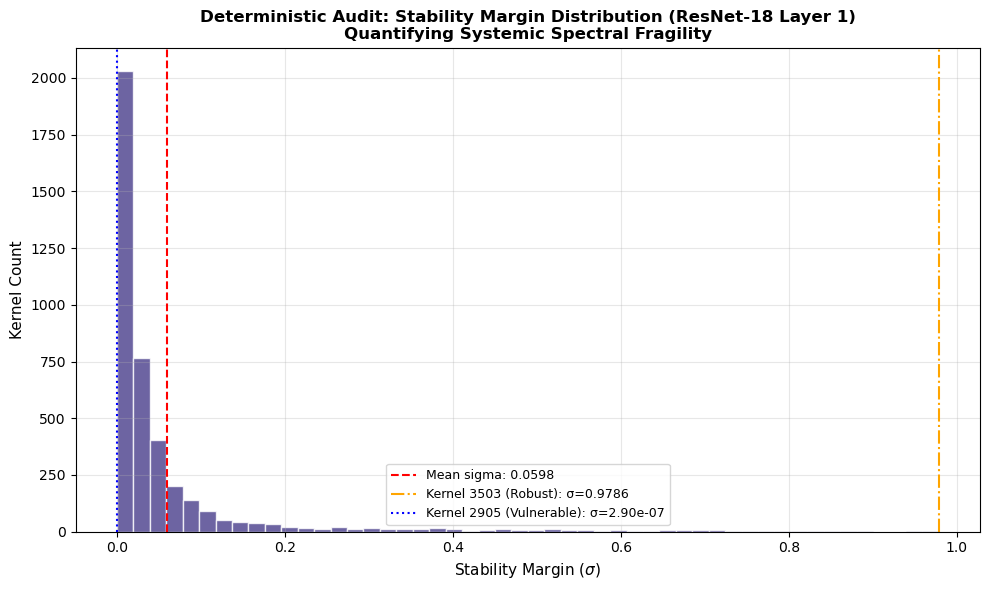

Saved: global_audit_histogram.png


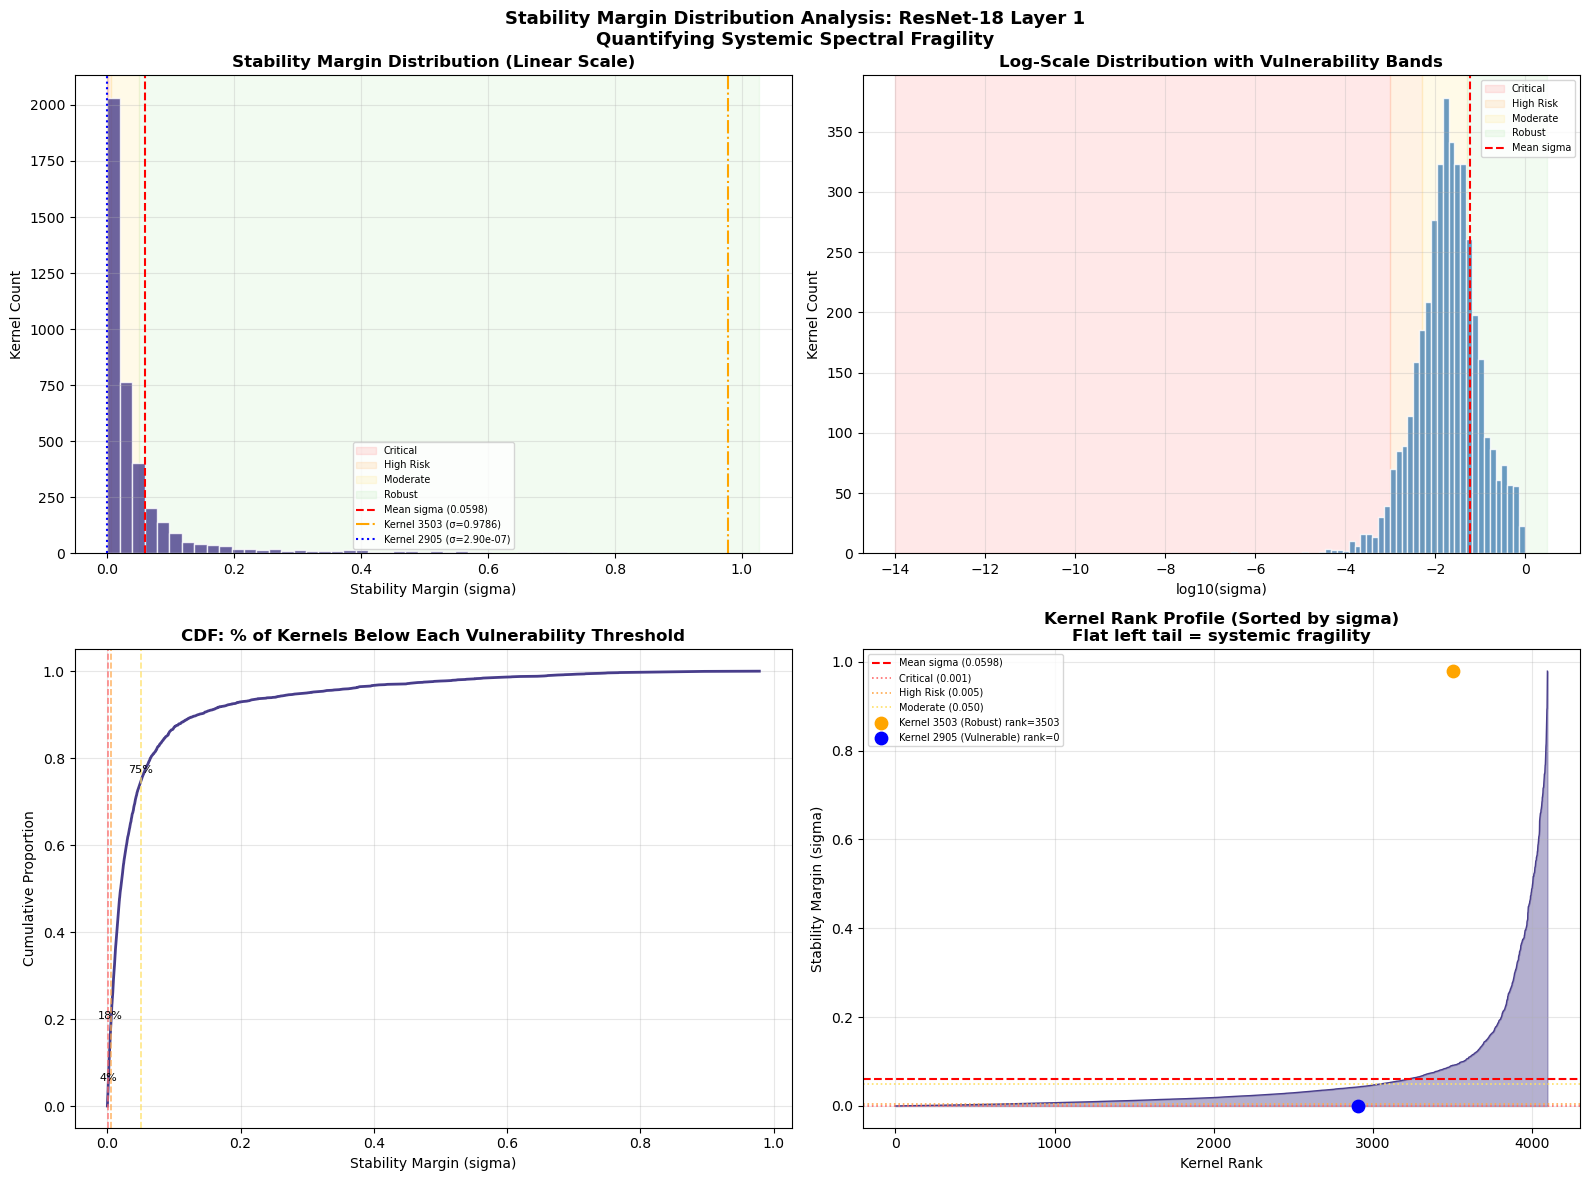

Saved: global_audit_full.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import (loadKernels, computeSigma,
                              IDXROBUST, IDXVULNERABLE, CSVPATH)

# ============================================================
# Load kernels and compute sigmas
# ============================================================
kernels = loadKernels(CSVPATH)

print("Computing sigmas for all 4096 kernels (this will take a few minutes)...")
sigmas = np.array([computeSigma(k) for k in kernels])
print(f"Done. Mean sigma: {np.mean(sigmas):.4f}")

# ============================================================
# Vulnerability band thresholds
# ============================================================
bands = [
    ('Critical',  0.000, 0.001, '#ff6b6b'),
    ('High Risk', 0.001, 0.005, '#ffa94d'),
    ('Moderate',  0.005, 0.050, '#ffe066'),
    ('Robust',    0.050, np.inf, '#a8e6a3'),
]

print("\n" + "="*60)
print("Vulnerability Classification — ResNet-18 Layer 1")
print("="*60)
print(f"  {'Band':<12} {'Range':<22} {'Count':>6}  {'%':>6}")
print("  " + "-"*50)
for name, lo, hi, _ in bands:
    count = np.sum((sigmas >= lo) & (sigmas < hi))
    pct   = 100 * count / len(sigmas)
    hi_str = f"{hi:.3f}" if hi != np.inf else "∞"
    print(f"  {name:<12} [{lo:.3f}, {hi_str})        {count:>6}  {pct:>5.1f}%")
print(f"\n  Mean sigma:   {np.mean(sigmas):.4f}")
print(f"  Median sigma: {np.median(sigmas):.4f}")
print(f"  Max sigma:    {np.max(sigmas):.4f}  (Kernel {np.argmax(sigmas)})")
print(f"  Min sigma:    {np.min(sigmas):.2e}  (Kernel {np.argmin(sigmas)})")

# ============================================================
# Figure 1: Simple histogram
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(sigmas, bins=50, color='darkslateblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(sigmas), color='red', linestyle='dashed', linewidth=1.5,
           label=f'Mean sigma: {np.mean(sigmas):.4f}')
ax.axvline(sigmas[IDXROBUST], color='orange', linestyle='dashdot', linewidth=1.5,
           label=f'Kernel {IDXROBUST} (Robust): σ={sigmas[IDXROBUST]:.4f}')
ax.axvline(sigmas[IDXVULNERABLE], color='blue', linestyle='dotted', linewidth=1.5,
           label=f'Kernel {IDXVULNERABLE} (Vulnerable): σ={sigmas[IDXVULNERABLE]:.2e}')
ax.set_title("Deterministic Audit: Stability Margin Distribution (ResNet-18 Layer 1)\n"
             "Quantifying Systemic Spectral Fragility",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Stability Margin ($\\sigma$)", fontsize=11)
ax.set_ylabel("Kernel Count", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("global_audit_histogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: global_audit_histogram.png")

# ============================================================
# Figure 2: Full distribution analysis (log scale, CDF, rank profile)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Stability Margin Distribution Analysis: ResNet-18 Layer 1\n"
             "Quantifying Systemic Spectral Fragility",
             fontsize=13, fontweight='bold')

# Top left: linear scale histogram with band shading
ax = axes[0, 0]
for name, lo, hi, color in bands:
    hi_plot = min(hi, sigmas.max() * 1.05)
    ax.axvspan(lo, hi_plot, alpha=0.15, color=color, label=name)
ax.hist(sigmas, bins=50, color='darkslateblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(sigmas), color='red', linestyle='dashed', linewidth=1.5,
           label=f'Mean sigma ({np.mean(sigmas):.4f})')
ax.axvline(sigmas[IDXROBUST], color='orange', linestyle='dashdot', linewidth=1.5,
           label=f'Kernel {IDXROBUST} (σ={sigmas[IDXROBUST]:.4f})')
ax.axvline(sigmas[IDXVULNERABLE], color='blue', linestyle='dotted', linewidth=1.5,
           label=f'Kernel {IDXVULNERABLE} (σ={sigmas[IDXVULNERABLE]:.2e})')
ax.set_title("Stability Margin Distribution (Linear Scale)", fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)")
ax.set_ylabel("Kernel Count")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Top right: log scale histogram with band shading
ax = axes[0, 1]
logSigmas = np.log10(sigmas + 1e-14)
for name, lo, hi, color in bands:
    lo_log = np.log10(lo + 1e-14)
    hi_log = np.log10(hi) if hi != np.inf else logSigmas.max() + 0.5
    ax.axvspan(lo_log, hi_log, alpha=0.15, color=color, label=name)
ax.hist(logSigmas, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.log10(np.mean(sigmas)), color='red', linestyle='dashed', linewidth=1.5,
           label=f'Mean sigma')
ax.set_title("Log-Scale Distribution with Vulnerability Bands", fontweight='bold')
ax.set_xlabel("log10(sigma)")
ax.set_ylabel("Kernel Count")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Bottom left: CDF
ax = axes[1, 0]
sortedSigmas = np.sort(sigmas)
cdf = np.arange(1, len(sortedSigmas) + 1) / len(sortedSigmas)
ax.plot(sortedSigmas, cdf, color='darkslateblue', linewidth=2)
for name, lo, hi, color in bands:
    if hi != np.inf:
        pct = np.mean(sigmas < hi)
        ax.axvline(hi, color=color, linewidth=1.2, linestyle='--', alpha=0.8)
        ax.text(hi, pct + 0.02, f'{100*pct:.0f}%', fontsize=8,
                color='black', ha='center')
ax.set_title("CDF: % of Kernels Below Each Vulnerability Threshold", fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)")
ax.set_ylabel("Cumulative Proportion")
ax.grid(True, alpha=0.3)

# Bottom right: rank profile
ax = axes[1, 1]
ax.fill_between(np.arange(len(sortedSigmas)), sortedSigmas, alpha=0.4,
                color='darkslateblue')
ax.plot(sortedSigmas, color='darkslateblue', linewidth=1)
ax.axhline(np.mean(sigmas), color='red', linestyle='dashed', linewidth=1.5,
           label=f'Mean sigma ({np.mean(sigmas):.4f})')
for name, lo, hi, color in bands[:-1]:
    ax.axhline(hi, color=color, linestyle='dotted', linewidth=1.2,
               label=f'{name} ({hi:.3f})')
ax.scatter([np.argmax(sigmas)], [sigmas[IDXROBUST]], color='orange', s=80,
           zorder=5, label=f'Kernel {IDXROBUST} (Robust) rank={np.argmax(sigmas)}')
ax.scatter([np.argmin(sigmas)], [sigmas[IDXVULNERABLE]], color='blue', s=80,
           zorder=5, label=f'Kernel {IDXVULNERABLE} (Vulnerable) rank=0')
ax.set_title("Kernel Rank Profile (Sorted by sigma)\nFlat left tail = systemic fragility",
             fontweight='bold')
ax.set_xlabel("Kernel Rank")
ax.set_ylabel("Stability Margin (sigma)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("global_audit_full.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: global_audit_full.png")